In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel( "EastWestAirlines.xlsx", sheet_name="data" )

In [3]:
df.shape

(3999, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


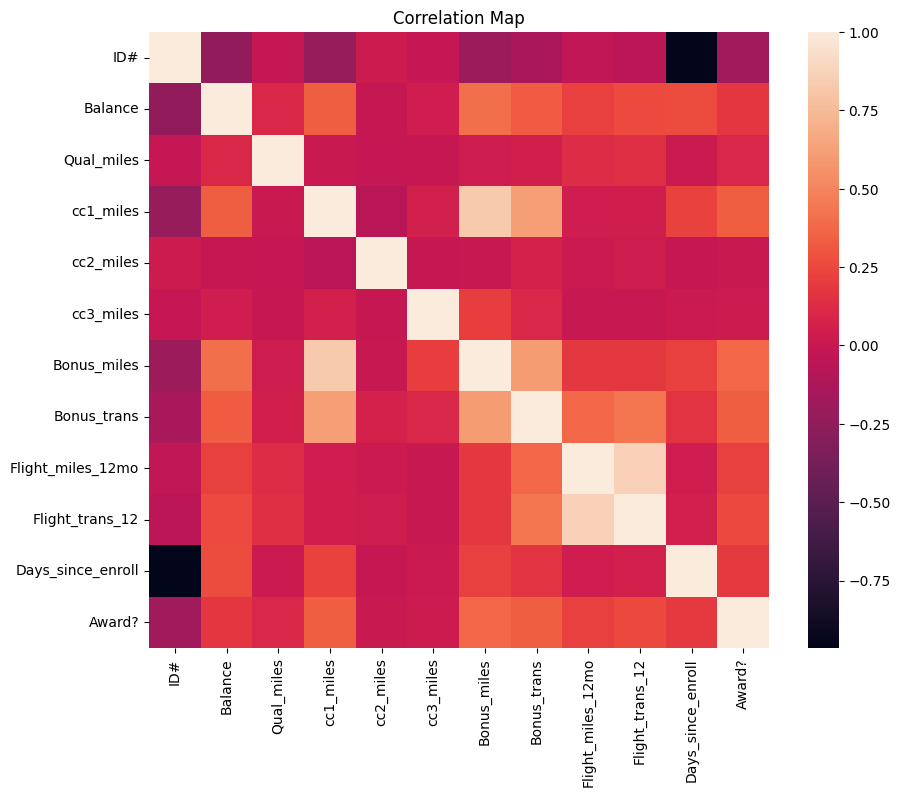

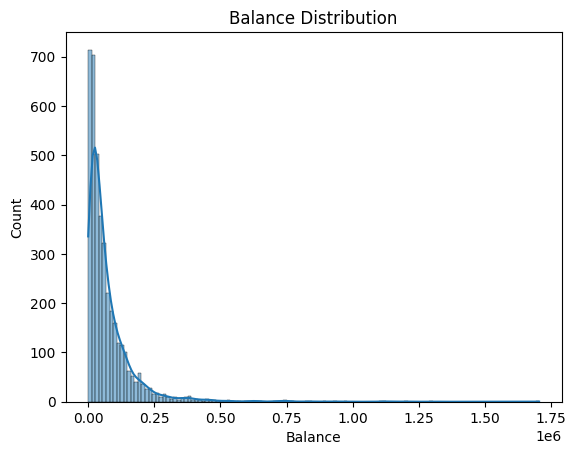

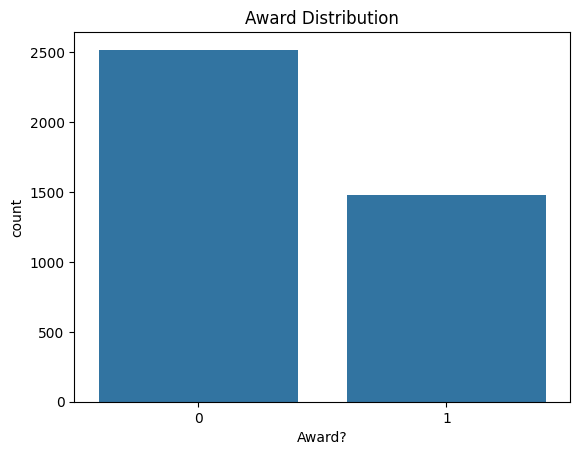

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Map")
plt.show()
sns.histplot(df["Balance"], kde=True)
plt.title("Balance Distribution")
plt.show()
sns.countplot(data=df, x="Award?")
plt.title("Award Distribution")
plt.show()

In [6]:
print("Missing Values:\n", df.isnull().sum())
for c in ["Balance", "Bonus_miles", "Bonus_trans"]:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    print(f"{c} Outlier Count:", ((df[c] < (q1 - 1.5 * iqr)) | (df[c] > (q3 + 1.5 * iqr))).sum())
df2 = df.drop(columns=["ID#"])

Missing Values:
 ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64
Balance Outlier Count: 266
Bonus_miles Outlier Count: 280
Bonus_trans Outlier Count: 63


In [7]:
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler( )
x = scaler.fit_transform( df2 )

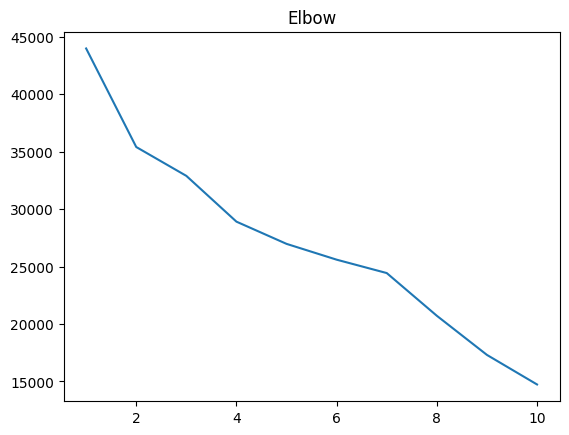

In [8]:
from sklearn.cluster import KMeans
wcss = []
for k in range( 1, 11 ):
    kmeans = KMeans( n_clusters=k, random_state= 42 )
    kmeans.fit( x )
    wcss.append( kmeans.inertia_ )
plt.plot( range( 1, 11 ), wcss )
plt.title( "Elbow" )
plt.show()

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
kmeans = KMeans( n_clusters=4, random_state=42 )
lbls_km = kmeans.fit_predict( x )
score_km = silhouette_score( x, lbls_km )
print( "KMeans Silhouette:", score_km )
df2["KMeans_Cluster"] = lbls_km

KMeans Silhouette: 0.19071186813310886


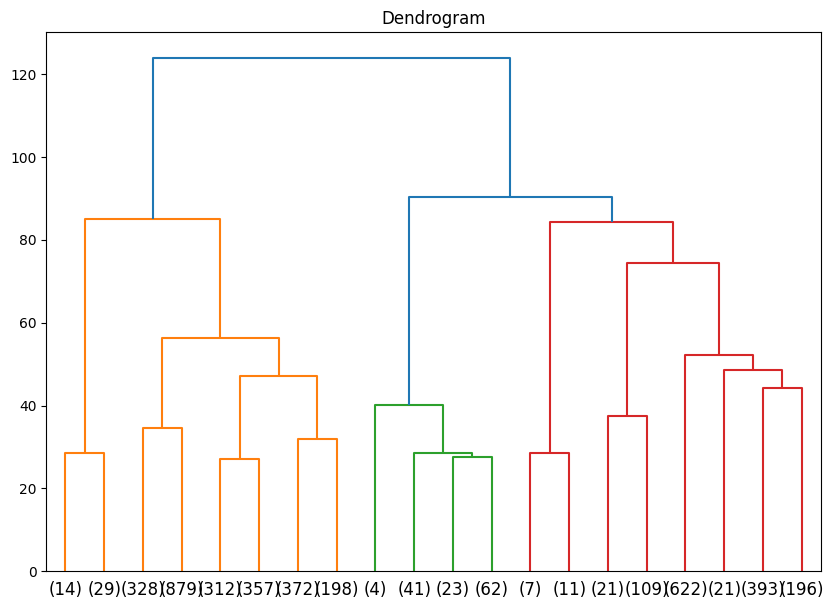

Hierarchical Silhouette: 0.30814152852022786


In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
lnk = linkage( x, method="ward" )
plt.figure(figsize=(10, 7))
dendrogram( lnk, truncate_mode="lastp", p=20 )
plt.title("Dendrogram")
plt.show()
hc = AgglomerativeClustering( n_clusters=4, linkage="ward" )
lbls_hc = hc.fit_predict( x )
score_hc = silhouette_score( x, lbls_hc )
print("Hierarchical Silhouette:", score_hc)
df2["HC_Cluster"] = lbls_hc

In [11]:
from sklearn.cluster import DBSCAN
for eps in [1.0, 1.5, 2.0]:
    for m_samp in [3, 5, 7]:
        db_test = DBSCAN(eps=eps, min_samples=m_samp)
        lbls_test = db_test.fit_predict(x)
        n_clusters = len(set(lbls_test)) - (1 if -1 in lbls_test else 0)
        n_noise = list(lbls_test).count(-1)
        print(f"eps={eps}, min_samples={m_samp} -> Clusters: {n_clusters}, Noise: {n_noise}")

eps=1.0, min_samples=3 -> Clusters: 10, Noise: 508
eps=1.0, min_samples=5 -> Clusters: 6, Noise: 554
eps=1.0, min_samples=7 -> Clusters: 5, Noise: 604
eps=1.5, min_samples=3 -> Clusters: 9, Noise: 277
eps=1.5, min_samples=5 -> Clusters: 5, Noise: 310
eps=1.5, min_samples=7 -> Clusters: 4, Noise: 338
eps=2.0, min_samples=3 -> Clusters: 12, Noise: 141
eps=2.0, min_samples=5 -> Clusters: 6, Noise: 179
eps=2.0, min_samples=7 -> Clusters: 5, Noise: 205


In [12]:
from sklearn.cluster import DBSCAN
db = DBSCAN( eps=1.5, min_samples=5 )
lbls_db = db.fit_predict( x )
score_db = silhouette_score( x, lbls_db )
print( "DBSCAN Silhouette:", score_db )
df2["DBSCAN_Cluster"] = lbls_db

DBSCAN Silhouette: 0.253747538041624


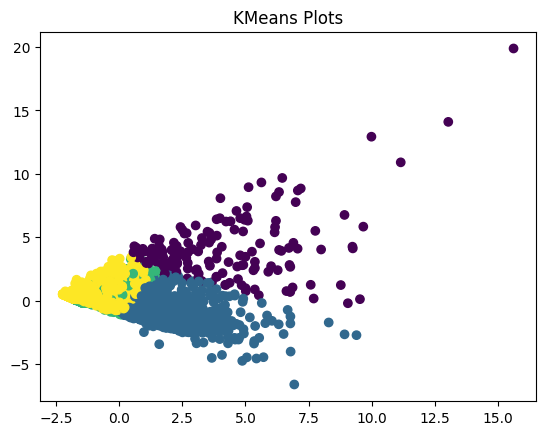

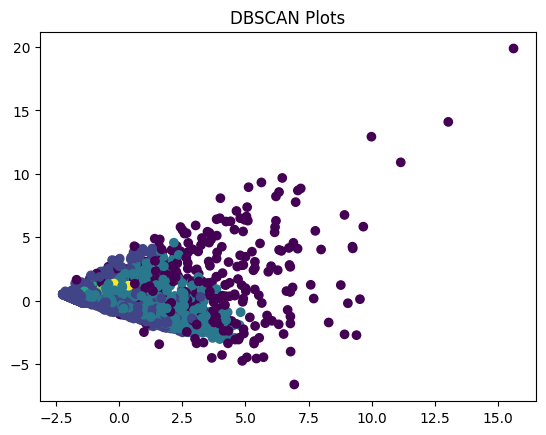

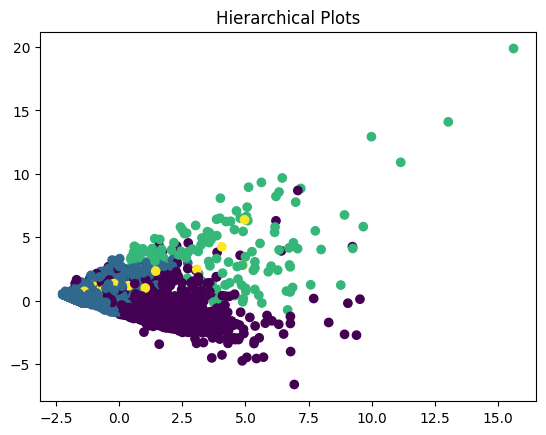

In [13]:
from sklearn.decomposition import PCA
pca = PCA( n_components=2 )
x_pca = pca.fit_transform( x )
plt.scatter( x_pca[:,0], x_pca[:,1], c=lbls_km )
plt.title( "KMeans Plots" )
plt.show()
plt.scatter( x_pca[:, 0], x_pca[:, 1], c=lbls_db )
plt.title( "DBSCAN Plots" )
plt.show()
plt.scatter( x_pca[:, 0], x_pca[:, 1], c=lbls_hc )
plt.title( "Hierarchical Plots" )
plt.show()

K-Means found four main customer types based on flight activities and credit card usage. DBSCAN clustered typical flyers together and separated outliers as noise, while hierarchical clustering displayed progressive tree-like linkages.